# Test GAN 

In [1]:
import os 
import sys 
import numpy as np 
import torch 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from src.dataset.custom_dataset import GenDataset, DiscDataset
from src.model.graph_model import NEGATGenerator, DiffPoolDiscriminator
from src.training.trainer import train_GAN

from utils.gen_utils import load_config, get_device, dataset_splitter, generate_markdown_report_GAN
from utils.ppnet_utils import initialize_network
from utils.load_data_utils import load_sampled_input_data

### Initialise the configuration and data for G and D 

In [2]:
yaml_config= load_config('config_gan.yaml')

device = get_device(yaml_config['device'])

net = initialize_network(net_name=yaml_config['data']['net_name'], 
                         load_std=yaml_config['data']['load_std']) 


Network: net_A is selected 

Net net_A has 42 nodes and 42 edges. 



In [3]:
########### data for generator 
sampled_input_data_G = load_sampled_input_data(sc_type=yaml_config['data']['gen_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])

# sparsity of the node and edge features 
node_feat_sparsity = np.count_nonzero(sampled_input_data_G['node_mask']) / sampled_input_data_G['node_mask'].numpy().size
pflow_edge_sparsity = np.count_nonzero(sampled_input_data_G['edge_mask'][:,:,0]) / sampled_input_data_G['edge_mask'][:,:,0].numpy().size

print(f"Sparsity of PV measurements at buses = {node_feat_sparsity:.1f}%")
print(f"Sparsity of P+ measurements at branches = {pflow_edge_sparsity:.1f}")

########### data for discriminator 
sampled_input_data_D = load_sampled_input_data(sc_type=yaml_config['data']['dis_scenario_type'], 
                                               net=net, 
                                               num_samples=yaml_config['data']['num_samples'], 
                                               noise=yaml_config['data']['noise'])

Selecting all the MV/LV transformers in the network 

Scaling inputs...
Number of V, P measurements 38 out of 84

Number of P_to, Q_to, P_from, Q_from measurements 5 out of 6

Sparsity of PV measurements at buses = 0.5%
Sparsity of P+ measurements at branches = 0.5
Scaling inputs...


### Make dataset and dataloader

In [4]:
dataset_G = GenDataset(model_name=yaml_config['model_G']['name'], 
                       sampled_input_data=sampled_input_data_G)

(train_loader_G, val_loader_G, test_loader_G), _ = dataset_splitter(dataset_G, 
                                                                    batch_size=yaml_config['loader']['batch_size'])

dataset_D = DiscDataset(sampled_input_data=sampled_input_data_D)

(train_loader_D, val_loader_D, test_loader_D), _ = dataset_splitter(dataset_D,
                                                                    batch_size=yaml_config['loader']['batch_size'])


Dataset for NEGATGenerator selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...



### Instantiate the model, optimizer, schedular 

In [5]:
# instantiate model, optimizer and schedular for Generator 
model_G = NEGATGenerator(node_input_features=dataset_G[0][0].x.shape[-1], 
                    list_node_hidden_features=yaml_config['model_G']['list_node_hidden_features'], # [128,64], 
                    node_out_features=yaml_config['model_G']['node_out_features'], # 64, 
                    k_hop_node=yaml_config['model_G']['k_hop_node'], #1, 
                    edge_input_features=dataset_G[0][1].x.shape[-1], 
                    list_edge_hidden_features=yaml_config['model_G']['list_edge_hidden_features'], #[128,64], 
                    edge_output_features=yaml_config['model_G']['edge_out_features'], #64, 
                    k_hop_edge=yaml_config['model_G']['k_hop_edge'], #1, 
                    gat_out_features=yaml_config['model_G']['gat_out_features'], #32, 
                    gat_head=yaml_config['model_G']['gat_head'], #2, 
                    device=device)

optimizer_G = torch.optim.Adam(model_G.parameters(), 
                            lr=yaml_config['training_G']['lr'], 
                            weight_decay=yaml_config['training_G']['weight_decay'])

schedular_G = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_G, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_G']['schedular_min_lr'])

total_params_G = sum(p.numel() for p in model_G.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_G}: {total_params_G}')


# instantiate model, optimizer and schedular for Discriminator 
model_D = DiffPoolDiscriminator(in_channel=dataset_D[0].x.shape[-1], 
                            hidden_channel=yaml_config['model_D']['hidden_channel'], 
                            out_channel=yaml_config['model_D']['out_channel'], 
                            num_nodes=len(net.bus.index))

total_params_D = sum(p.numel() for p in model_D.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model_D}: {total_params_D}')

optimizer_D = torch.optim.Adam(model_D.parameters(), 
                            lr=yaml_config['training_D']['lr'], 
                            weight_decay=yaml_config['training_D']['weight_decay'])

schedular_D = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_D, 
                                                    mode='min', 
                                                    factor=0.1, 
                                                    min_lr=yaml_config['training_D']['schedular_min_lr'])


Total number of parameters of model NEGATGenerator(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=1, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 7363
Total number of parameters of model DiffPoolDiscriminator(): 7243


### Train the GAN 

In [6]:
all_losses = train_GAN(model_G=model_G, 
                        model_D=model_D, 
                        all_loader_G= [train_loader_G, val_loader_G, test_loader_G], 
                        all_loader_D= [train_loader_D, val_loader_D, test_loader_D], 
                        optimizer_G=optimizer_G, 
                        optimizer_D=optimizer_D, 
                        schedular_G=schedular_G, 
                        schedular_D=schedular_D, 
                        num_epoch=yaml_config['training_GAN']['num_epoch'], 
                        disc_iter=yaml_config['training_GAN']['disc_iter'], 
                        gen_iter=yaml_config['training_GAN']['gen_iter'],
                        feature_matching=yaml_config['training_GAN']['feature_matching'],   
                        device=device)  

At epoch: 0
training: D = 2.759e+01, Acc = 0.96, G = 8.503e+01
validation: D = 2.118e+01, Acc = 1.00, G = 3.504e+01, lr_D = 1.0e-02, lr_G 1.0e-02
------------------------------------------------------------------------------
At epoch: 2
training: D = 9.978e+01, Acc = 1.00, G = 4.633e+01
validation: D = 5.679e+01, Acc = 1.00, G = 4.448e+01, lr_D = 1.0e-02, lr_G 1.0e-02
------------------------------------------------------------------------------
At epoch: 4
training: D = 1.374e+02, Acc = 1.00, G = 1.788e+01
validation: D = 6.740e+01, Acc = 1.00, G = 1.238e+01, lr_D = 1.0e-02, lr_G 1.0e-02
------------------------------------------------------------------------------
At epoch: 6
training: D = 1.361e+02, Acc = 1.00, G = 1.227e+01
validation: D = 6.721e+01, Acc = 1.00, G = 1.266e+01, lr_D = 1.0e-02, lr_G 1.0e-02
------------------------------------------------------------------------------
At epoch: 8
training: D = 1.326e+02, Acc = 1.00, G = 1.343e+01
validation: D = 6.617e+01, Acc = 1.00

In [8]:
all_losses 

{'train_g_losses': [85.02822729257437,
  35.7209070279048,
  46.32678274007944,
  102.48471667216374,
  17.876358637442955,
  14.27486804815439,
  12.267989892226,
  13.139754680486826,
  13.434098738890428,
  13.930640128942636,
  14.27489759371831,
  14.68819339458759,
  14.777083616990309,
  14.774612683516283,
  14.780919826947725,
  14.768734290049625,
  14.77932988680326,
  14.788360265585093,
  14.835774219953096,
  14.890538692474365,
  14.936131642414974,
  14.988250714081984,
  15.036649960737963,
  15.065257255847637,
  15.063105234732994,
  15.06815057534438,
  15.073325835741484,
  15.072534249379085,
  15.07654958504897,
  15.081890197900625,
  15.086165831639217,
  15.098088631263145,
  15.11161732673645,
  15.112684946793776,
  15.116260436865,
  15.115583969996525,
  15.11516602222736,
  15.122052100988535,
  15.117052665123573,
  15.12017690218412,
  15.11869241641118,
  15.122861000207754,
  15.123284945121178,
  15.12758785027724,
  15.12509428537809,
  15.128292578

### Results 

Saved in `results/GAN_results/{current_time}`

/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/.venv/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'fontsize'
  cset = contour_func(


📄 Training report saved to: /Users/sohamprajapati/Documents/Thesis/Project Codes/TapSEGNN/results/GAN_only/20250912_114753/training_report.md


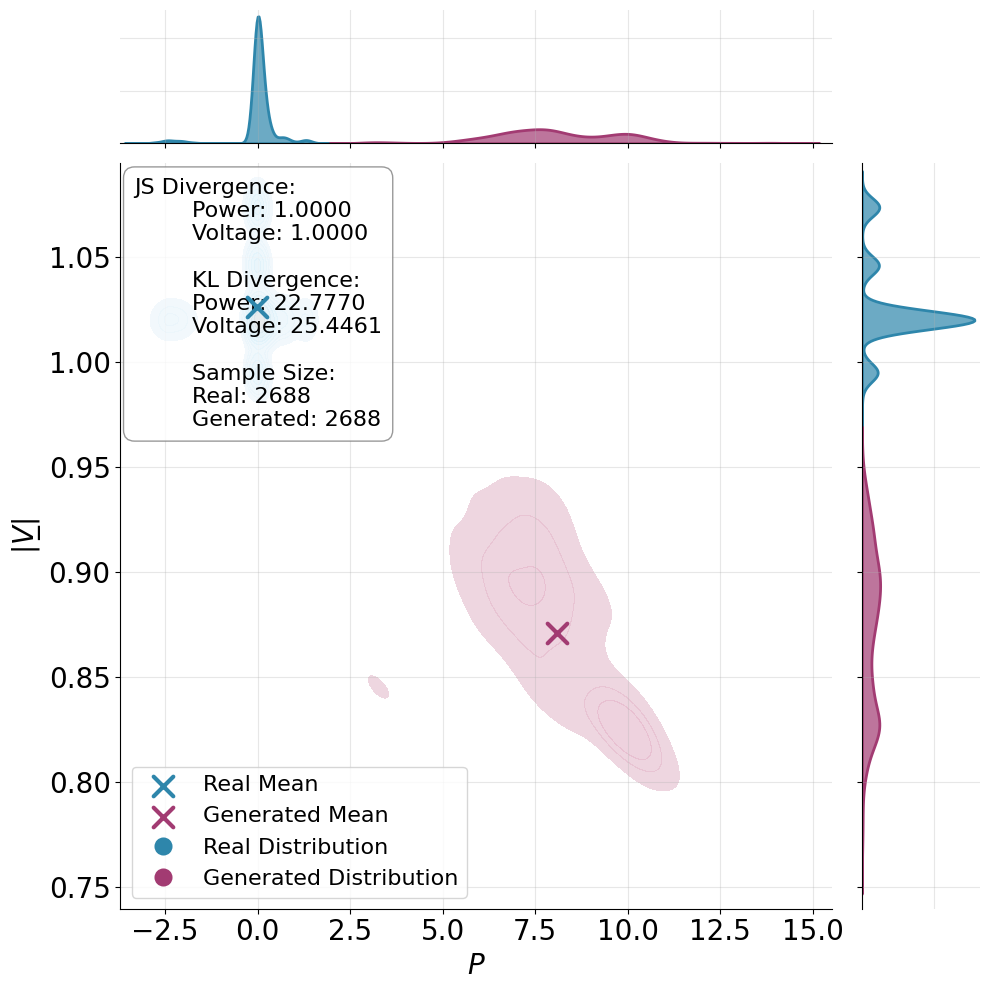

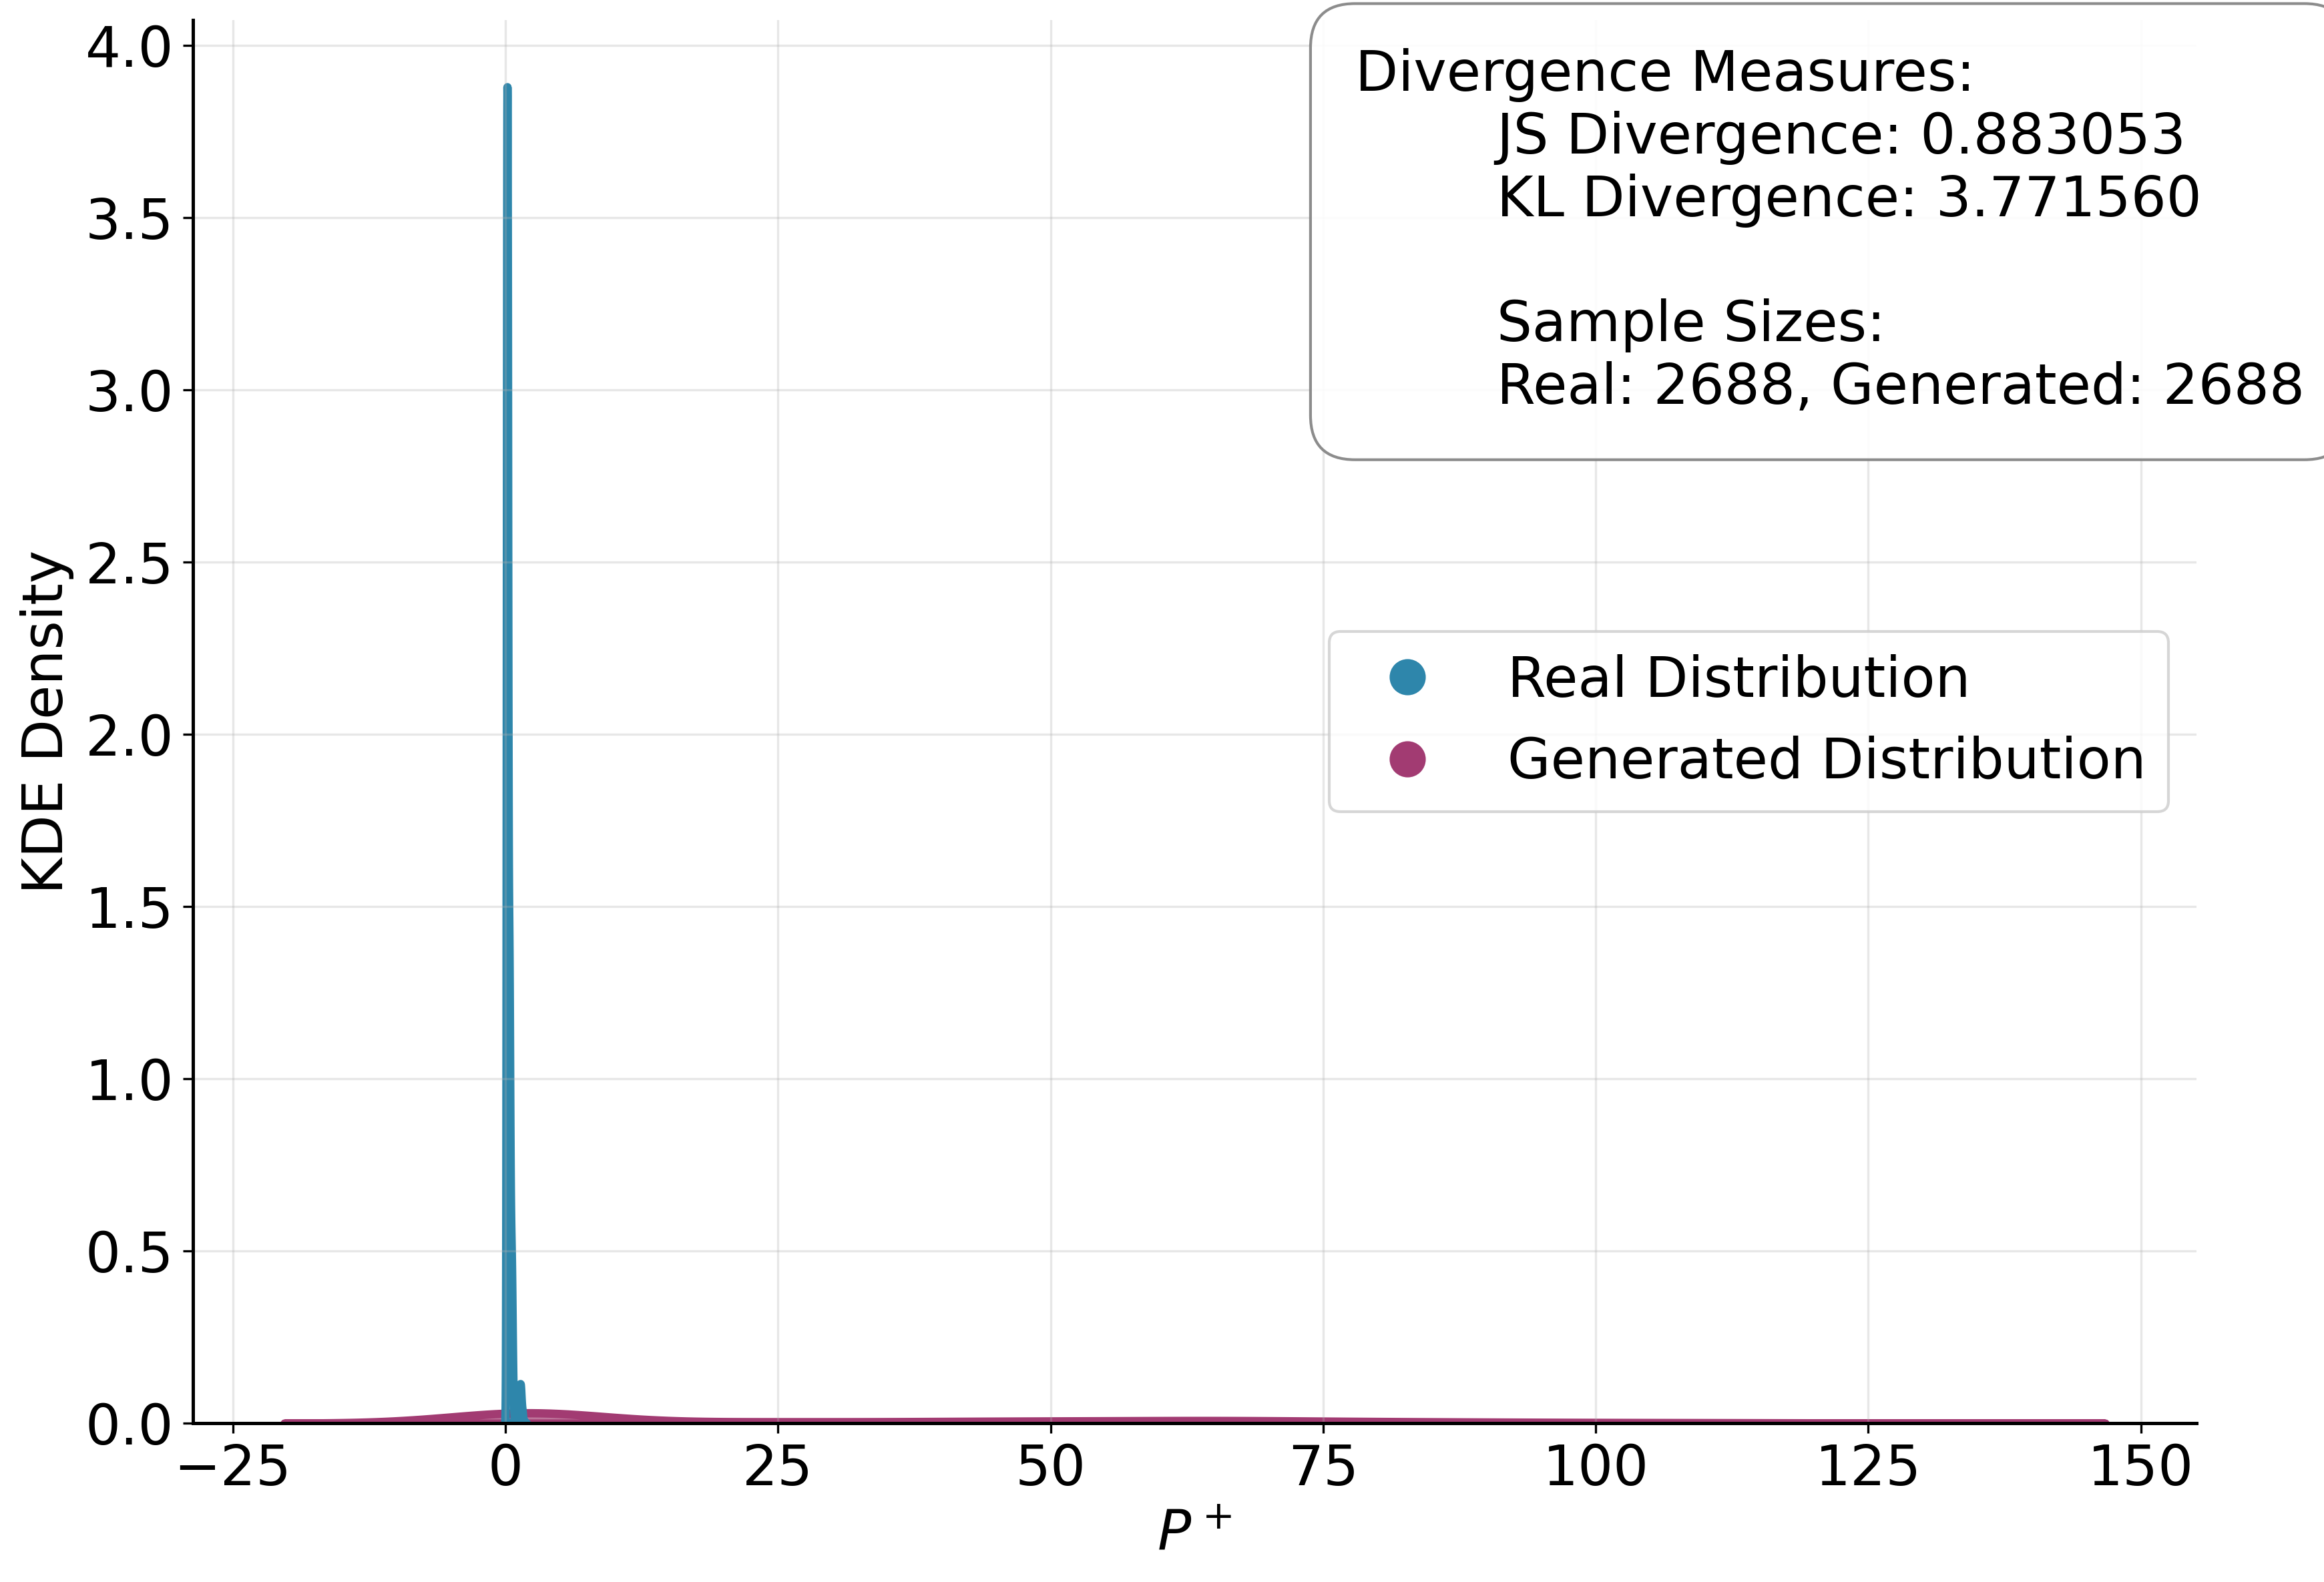

In [7]:
generate_markdown_report_GAN(yaml_config=yaml_config, 
                             train_g_losses=all_losses['train_g_losses'], 
                             train_d_losses=all_losses['train_d_losses'], 
                             train_d_accuracies=all_losses['train_d_accuracies'],
                             parent_dir=parent_dir, 
                             test_loader_G=test_loader_G, 
                             model_G=model_G, 
                             sampled_input_data_G=sampled_input_data_G)